Input: i love you
Output: t t t aime


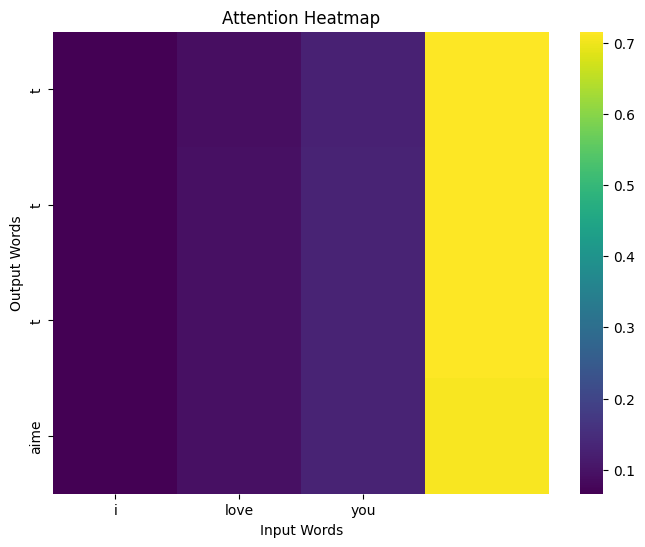

In [3]:
# 🔹 Encoder model for inference
encoder_model = Model(encoder_inputs, [encoder_outputs, state_h, state_c])

# 🔹 Prediction + attention capture
def predict_with_attention(input_sentence):
    seq = input_tokenizer.texts_to_sequences([input_sentence])
    seq = pad_sequences(seq, maxlen=max_input_len, padding='post')

    enc_out, h, c = encoder_model.predict(seq, verbose=0)

    target_seq = np.zeros((1, 1))
    attention_plot = []
    decoded_sentence = []

    for _ in range(max_target_len):
        dec_emb_step = tf.keras.layers.Embedding(vocab_out, latent_dim)(target_seq)
        dec_out, h, c = decoder_lstm(dec_emb_step, initial_state=[h, c])

        context, attn = attention(h, enc_out)
        attention_plot.append(attn[0].numpy())

        context = tf.expand_dims(context, 1)
        combined = tf.concat([dec_out, context], axis=-1)

        preds = output_dense(combined)
        token = np.argmax(preds[0, -1, :])

        if token == 0:
            break

        word = target_tokenizer.index_word.get(token, '')
        decoded_sentence.append(word)

        target_seq = np.array([[token]])

    return input_sentence, " ".join(decoded_sentence), np.array(attention_plot)


# 🔹 Heatmap function (IMPORTANT 🔥)
def plot_attention(input_sentence, output_sentence, attention):
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        attention,
        xticklabels=input_sentence.split(),
        yticklabels=output_sentence.split(),
        cmap="viridis"
    )
    plt.xlabel("Input Words")
    plt.ylabel("Output Words")
    plt.title("Attention Heatmap")
    plt.show()


# 🔹 Run
inp, out, attn = predict_with_attention("i love you")

print("Input:", inp)
print("Output:", out)

plot_attention(inp, out, attn)